In [1]:
import requests
import pandas as pd
from io import StringIO
from pathlib import Path
import time

# ============================================
# NOAA CO-OPS downloader
# Station: 8536110 Cape May, NJ
# Products:
#   1) Verified hourly water levels
#   2) Hourly tidal predictions
# Settings:
#   - Metric units
#   - MSL datum
#   - GMT time zone
# Period:
#   - 1995 to 2025
# ============================================

BASE_URL = "https://api.tidesandcurrents.noaa.gov/api/prod/datagetter"
STATION = "8536110"
DATUM = "MSL"
UNITS = "metric"
TIME_ZONE = "gmt"
START_YEAR = 1995
END_YEAR = 2025
OUT_DIR = Path(r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\cape_may_noaa")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# NOAA hourly products are limited to 1 year per request, so request one year at a time.
# Official docs: product=hourly_height for verified hourly water levels,
# and product=predictions with interval=h for hourly tide predictions.

def fetch_noaa_csv(params: dict) -> pd.DataFrame:
    """
    Fetch NOAA CO-OPS data as CSV and return as a DataFrame.
    Raises an error if the request fails or NOAA returns an error message.
    """
    params = params.copy()
    params["format"] = "csv"
    params["application"] = "homework_5_cape_may"

    response = requests.get(BASE_URL, params=params, timeout=60)
    response.raise_for_status()

    text = response.text.strip()

    # NOAA sometimes returns plain-text error messages instead of CSV
    if not text:
        raise ValueError("Empty response received from NOAA API.")

    # Common NOAA error responses do not begin with a CSV header
    if text.lower().startswith("error") or "wrong" in text.lower() or "invalid" in text.lower():
        raise ValueError(f"NOAA API error:\n{text}")

    return pd.read_csv(StringIO(text))


def download_hourly_water_levels(start_year: int, end_year: int) -> pd.DataFrame:
    """
    Download verified hourly water levels (product=hourly_height)
    in metric units, MSL datum, GMT.
    """
    frames = []

    for year in range(start_year, end_year + 1):
        print(f"Downloading hourly water levels for {year}...")
        params = {
            "begin_date": f"{year}0101",
            "end_date": f"{year}1231",
            "station": STATION,
            "product": "hourly_height",
            "datum": DATUM,
            "units": UNITS,
            "time_zone": TIME_ZONE,
        }

        try:
            df = fetch_noaa_csv(params)
            df["source_product"] = "hourly_height"
            frames.append(df)
        except Exception as e:
            print(f"  Failed for water levels {year}: {e}")

        time.sleep(0.2)  # be polite to the API

    if not frames:
        raise RuntimeError("No hourly water level data were downloaded.")

    out = pd.concat(frames, ignore_index=True)

    # Standard cleanup
    if "Date Time" in out.columns:
        out["Date Time"] = pd.to_datetime(out["Date Time"], errors="coerce", utc=True)

    return out


def download_hourly_predictions(start_year: int, end_year: int) -> pd.DataFrame:
    """
    Download hourly tidal predictions (product=predictions, interval=h)
    in metric units, MSL datum, GMT.
    """
    frames = []

    for year in range(start_year, end_year + 1):
        print(f"Downloading hourly tidal predictions for {year}...")
        params = {
            "begin_date": f"{year}0101",
            "end_date": f"{year}1231",
            "station": STATION,
            "product": "predictions",
            "interval": "h",
            "datum": DATUM,
            "units": UNITS,
            "time_zone": TIME_ZONE,
        }

        try:
            df = fetch_noaa_csv(params)
            df["source_product"] = "predictions"
            frames.append(df)
        except Exception as e:
            print(f"  Failed for predictions {year}: {e}")

        time.sleep(0.2)

    if not frames:
        raise RuntimeError("No tidal prediction data were downloaded.")

    out = pd.concat(frames, ignore_index=True)

    # Standard cleanup
    if "Date Time" in out.columns:
        out["Date Time"] = pd.to_datetime(out["Date Time"], errors="coerce", utc=True)

    return out


def main():
    # Download both datasets
    wl = download_hourly_water_levels(START_YEAR, END_YEAR)
    pred = download_hourly_predictions(START_YEAR, END_YEAR)

    # Save full datasets
    wl_file = OUT_DIR / "cape_may_8536110_hourly_water_level_1995_2025_MSL_metric_GMT.csv"
    pred_file = OUT_DIR / "cape_may_8536110_hourly_predictions_1995_2025_MSL_metric_GMT.csv"

    wl.to_csv(wl_file, index=False)
    pred.to_csv(pred_file, index=False)

    print("\nSaved files:")
    print(wl_file)
    print(pred_file)

    # Optional: merge by timestamp if you want observed vs predicted side by side
    if "Date Time" in wl.columns and "Date Time" in pred.columns:
        # NOAA usually names the value column differently by product.
        # Rename defensively if the columns exist.
        wl_renamed = wl.copy()
        pred_renamed = pred.copy()

        if " Water Level" in wl_renamed.columns:
            wl_renamed = wl_renamed.rename(columns={" Water Level": "observed_wl_m"})
        if " Prediction" in pred_renamed.columns:
            pred_renamed = pred_renamed.rename(columns={" Prediction": "predicted_wl_m"})

        merged = pd.merge(
            wl_renamed,
            pred_renamed,
            on="Date Time",
            how="outer",
            suffixes=("_obs", "_pred")
        ).sort_values("Date Time")

        merged_file = OUT_DIR / "cape_may_8536110_observed_and_predicted_hourly_1995_2025_MSL_metric_GMT.csv"
        merged.to_csv(merged_file, index=False)
        print(merged_file)


if __name__ == "__main__":
    main()


Saved files:
D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\cape_may_noaa\cape_may_8536110_hourly_water_level_1995_2025_MSL_metric_GMT.csv
D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\cape_may_noaa\cape_may_8536110_hourly_predictions_1995_2025_MSL_metric_GMT.csv
D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\cape_may_noaa\cape_may_8536110_observed_and_predicted_hourly_1995_2025_MSL_metric_GMT.csv


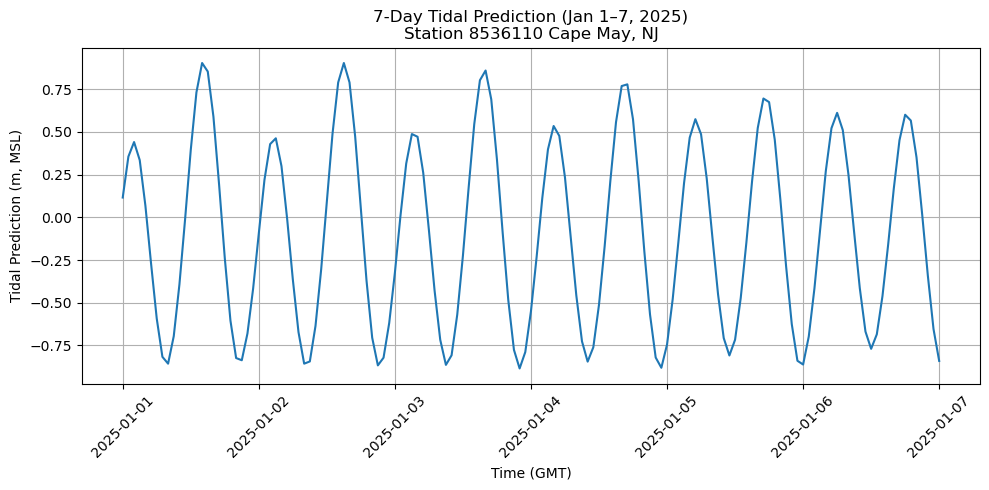

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# File path
# -----------------------------
file_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\cape_may_noaa\cape_may_8536110_observed_and_predicted_hourly_1995_2025_MSL_metric_GMT.csv"

# -----------------------------
# Read CSV
# -----------------------------
df = pd.read_csv(file_path)

# -----------------------------
# Convert time column
# -----------------------------
df["Date Time"] = pd.to_datetime(df["Date Time"], errors="coerce")

# -----------------------------
# Select 7-day period (example: Jan 1–7, 2025)
# -----------------------------
start_date = "2025-01-01"
end_date = "2025-01-07"

df_7day = df[(df["Date Time"] >= start_date) & (df["Date Time"] <= end_date)]

# -----------------------------
# Extract data
# -----------------------------
time = df_7day["Date Time"]
wl = df_7day["predicted_wl_m"]

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10,5))

plt.plot(time, wl, linewidth=1.5)

plt.xlabel("Time (GMT)")
plt.ylabel("Tidal Prediction (m, MSL)")
plt.title("7-Day Tidal Prediction (Jan 1–7, 2025)\nStation 8536110 Cape May, NJ")

plt.grid(True)

# Improve x-axis formatting
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

MHHW = 0.958 m (MSL)


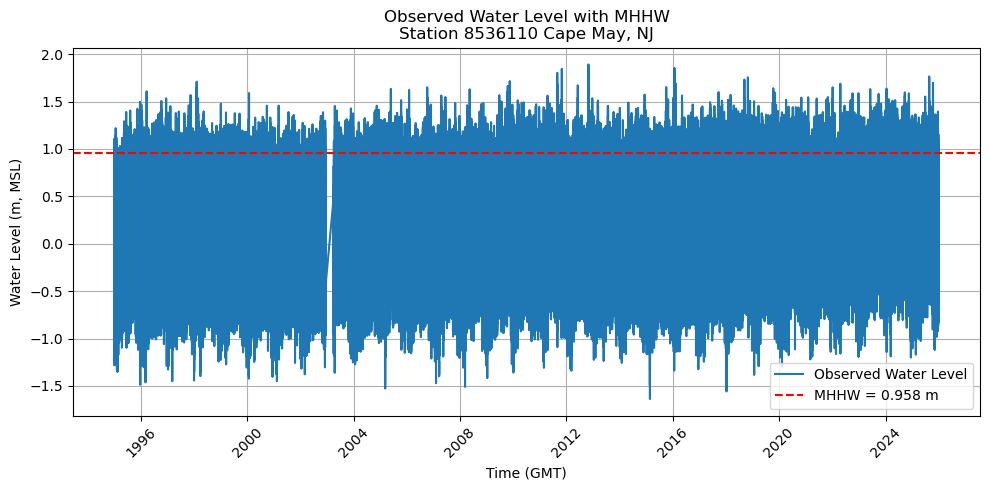

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# -----------------------------
# File path
# -----------------------------
file_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\cape_may_noaa\cape_may_8536110_observed_and_predicted_hourly_1995_2025_MSL_metric_GMT.csv"

# -----------------------------
# Read data
# -----------------------------
df = pd.read_csv(file_path)

# Convert time column
df["Date Time"] = pd.to_datetime(df["Date Time"], errors="coerce")

# Remove NaN values
df = df.dropna(subset=["observed_wl_m"])

# Sort (important)
df = df.sort_values("Date Time")

# Extract arrays
time = df["Date Time"]
wl = df["observed_wl_m"].values

# -----------------------------
# Find all high tides (peaks)
# -----------------------------
peaks, _ = find_peaks(wl, distance=8)  
# distance=8 → avoids detecting noise (approx 8 hours spacing)

peak_times = time.iloc[peaks]
peak_values = wl[peaks]

# -----------------------------
# Create peak dataframe
# -----------------------------
df_peaks = pd.DataFrame({
    "time": peak_times,
    "wl": peak_values
})

df_peaks["date"] = df_peaks["time"].dt.date

# -----------------------------
# Select Higher High Water per day
# -----------------------------
daily_hhw = df_peaks.loc[df_peaks.groupby("date")["wl"].idxmax()]

# -----------------------------
# Compute MHHW
# -----------------------------
MHHW = daily_hhw["wl"].mean()

print(f"MHHW = {MHHW:.3f} m (MSL)")

# -----------------------------
# Plot (sample portion for clarity)
# -----------------------------
# Plot only a short window (e.g., Jan 2025) for visualization
plot_df = df[(df["Date Time"] >= "1995-01-01") & (df["Date Time"] <= "2025-12-31")]

plt.figure(figsize=(10,5))

plt.plot(plot_df["Date Time"], plot_df["observed_wl_m"], label="Observed Water Level")

# Plot MHHW line
plt.axhline(MHHW, color='red', linestyle='--', label=f"MHHW = {MHHW:.3f} m")

plt.xlabel("Time (GMT)")
plt.ylabel("Water Level (m, MSL)")
plt.title("Observed Water Level with MHHW\nStation 8536110 Cape May, NJ")

plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

                     time_x    obs        date                    time_y  \
0 1995-01-01 13:00:00+00:00  1.106  1995-01-01 1995-01-01 13:00:00+00:00   
1 1995-01-02 14:00:00+00:00  0.856  1995-01-02 1995-01-02 14:00:00+00:00   
2 1995-01-03 15:00:00+00:00  0.829  1995-01-03 1995-01-03 15:00:00+00:00   
3 1995-01-04 16:00:00+00:00  0.738  1995-01-04 1995-01-04 16:00:00+00:00   
4 1995-01-05 16:00:00+00:00  0.515  1995-01-05 1995-01-05 16:00:00+00:00   

    pred  skew_surge  
0  1.090       0.016  
1  1.081      -0.225  
2  1.020      -0.191  
3  0.913      -0.175  
4  0.813      -0.298  


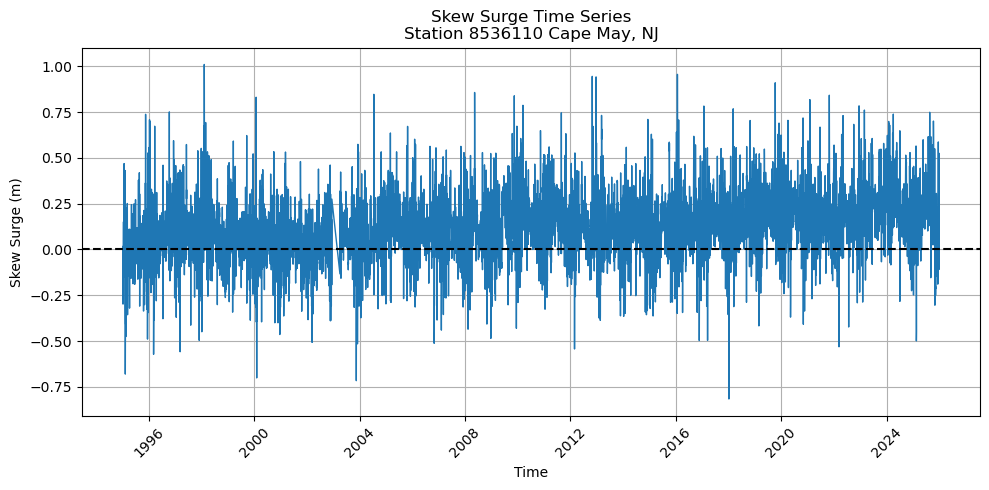

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# -----------------------------
# File path
# -----------------------------
file_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\cape_may_noaa\cape_may_8536110_observed_and_predicted_hourly_1995_2025_MSL_metric_GMT.csv"

# -----------------------------
# Read data
# -----------------------------
df = pd.read_csv(file_path)

df["Date Time"] = pd.to_datetime(df["Date Time"], errors="coerce")

# Drop NaN
df = df.dropna(subset=["observed_wl_m", "predicted_wl_m"])

# Sort
df = df.sort_values("Date Time")

# -----------------------------
# Extract arrays
# -----------------------------
time = df["Date Time"]
obs = df["observed_wl_m"].values
pred = df["predicted_wl_m"].values

# -----------------------------
# Find high tides (peaks)
# -----------------------------
# distance=8 → avoids noise (~8 hours between tides)
obs_peaks, _ = find_peaks(obs, distance=8)
pred_peaks, _ = find_peaks(pred, distance=8)

# Create dataframes
obs_df = pd.DataFrame({
    "time": time.iloc[obs_peaks],
    "obs": obs[obs_peaks]
})

pred_df = pd.DataFrame({
    "time": time.iloc[pred_peaks],
    "pred": pred[pred_peaks]
})

# Extract date
obs_df["date"] = obs_df["time"].dt.date
pred_df["date"] = pred_df["time"].dt.date

# -----------------------------
# Select Higher High Water (per day)
# -----------------------------
obs_hhw = obs_df.loc[obs_df.groupby("date")["obs"].idxmax()]
pred_hhw = pred_df.loc[pred_df.groupby("date")["pred"].idxmax()]

# -----------------------------
# Merge observed and predicted
# -----------------------------
merged = pd.merge(obs_hhw, pred_hhw, on="date")

# -----------------------------
# Compute skew surge
# -----------------------------
merged["skew_surge"] = merged["obs"] - merged["pred"]

print(merged.head())

# -----------------------------
# Plot skew surge time series
# -----------------------------
plt.figure(figsize=(10,5))

plt.plot(merged["time_x"], merged["skew_surge"], linewidth=1)

plt.axhline(0, color='black', linestyle='--')

plt.xlabel("Time")
plt.ylabel("Skew Surge (m)")
plt.title("Skew Surge Time Series\nStation 8536110 Cape May, NJ")

plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


Daily HHW-based skew surge sample:
        date  obs_high  pred_high  skew_surge
0 1995-01-01     1.106      1.090       0.016
1 1995-01-02     0.856      1.081      -0.225
2 1995-01-03     0.829      1.020      -0.191
3 1995-01-04     0.738      0.913      -0.175
4 1995-01-05     0.515      0.813      -0.298

Annual maximum skew surge values:
    year  skew_surge
0   1995       0.738
1   1996       0.751
2   1997       0.573
3   1998       1.010
4   1999       0.622
5   2000       0.831
6   2001       0.532
7   2002       0.461
8   2003       0.574
9   2004       0.847
10  2005       0.672
11  2006       0.602
12  2007       0.563
13  2008       0.857
14  2009       0.839
15  2010       0.787
16  2011       0.746
17  2012       0.945
18  2013       0.732
19  2014       0.710
20  2015       0.629
21  2016       0.956
22  2017       0.783
23  2018       0.768
24  2019       0.910
25  2020       0.718
26  2021       0.842
27  2022       0.784
28  2023       0.761
29  2024       0.739
30

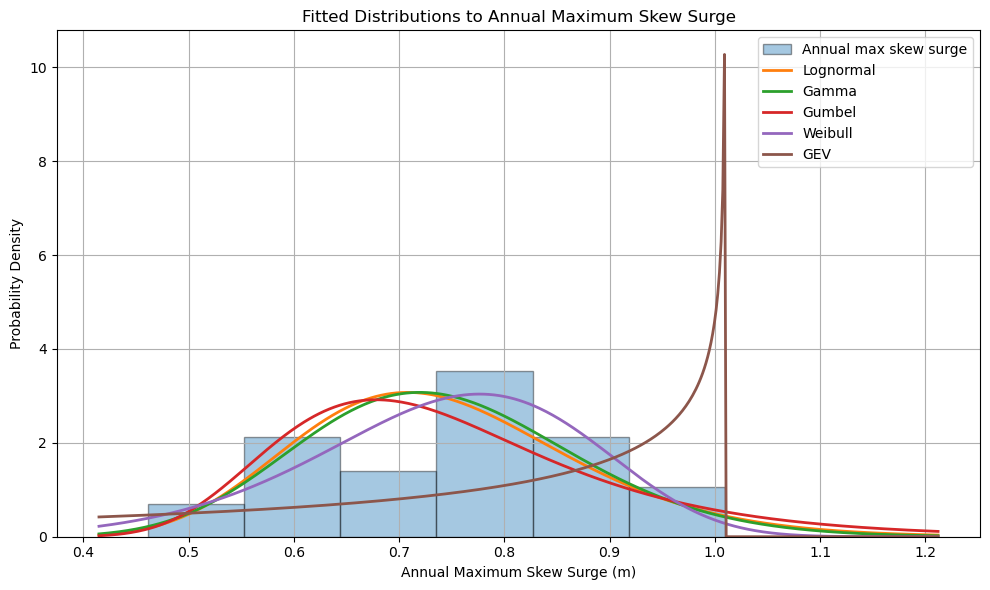

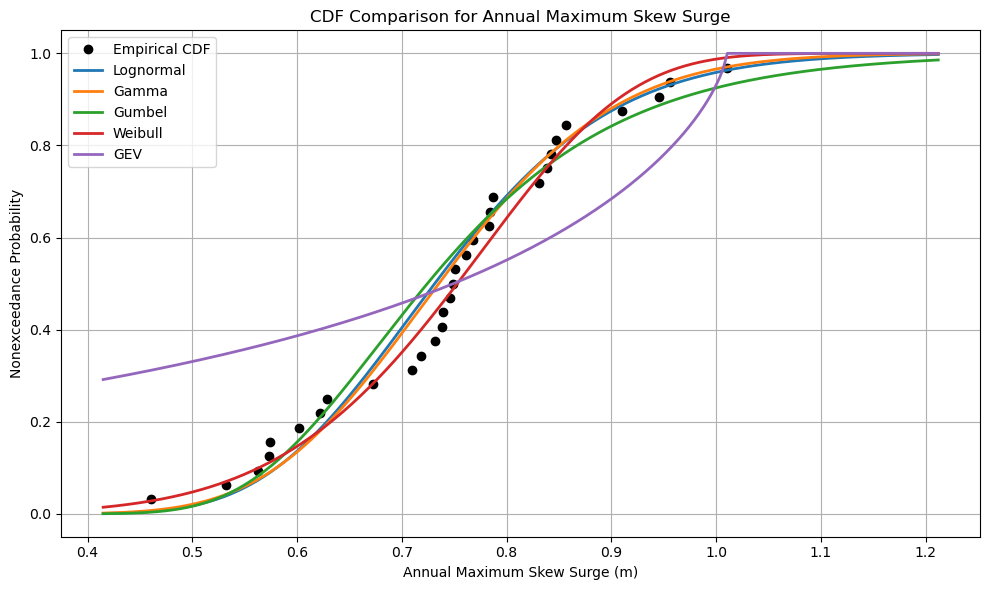


Estimated return levels (m):
 Return Period (yr)  Lognormal    Gamma   Gumbel  Weibull      GEV
                2.0   0.731337 0.735197 0.724315 0.752900 0.749165
                5.0   0.851189 0.850711 0.867194 0.857102 0.958641
               10.0   0.921463 0.915592 0.961793 0.905663 0.992487
               25.0   1.002805 0.988263 1.081318 0.953573 1.005503
               50.0   1.059132 1.037148 1.169989 0.982622 1.008360
              100.0   1.112494 1.082435 1.258005 1.007599 1.009397


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy import stats

# =========================================================
# File path
# =========================================================
file_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\cape_may_noaa\cape_may_8536110_observed_and_predicted_hourly_1995_2025_MSL_metric_GMT.csv"

# =========================================================
# Read and clean data
# =========================================================
df = pd.read_csv(file_path)

df["Date Time"] = pd.to_datetime(df["Date Time"], errors="coerce")
df = df.dropna(subset=["Date Time", "observed_wl_m", "predicted_wl_m"]).copy()
df = df.sort_values("Date Time").reset_index(drop=True)

# =========================================================
# Extract arrays
# =========================================================
time = df["Date Time"]
obs = df["observed_wl_m"].values
pred = df["predicted_wl_m"].values

# =========================================================
# Find peaks (high tides)
# distance=8 assumes hourly data and avoids false peaks from noise
# =========================================================
obs_peaks, _ = find_peaks(obs, distance=8)
pred_peaks, _ = find_peaks(pred, distance=8)

# =========================================================
# Create dataframes of peaks
# =========================================================
obs_df = pd.DataFrame({
    "time_obs": time.iloc[obs_peaks].values,
    "obs_high": obs[obs_peaks]
})

pred_df = pd.DataFrame({
    "time_pred": time.iloc[pred_peaks].values,
    "pred_high": pred[pred_peaks]
})

# =========================================================
# Create daily grouping key
# IMPORTANT: use .dt.floor("D"), not .date on a Series
# =========================================================
obs_df["date"] = pd.to_datetime(obs_df["time_obs"]).dt.floor("D")
pred_df["date"] = pd.to_datetime(pred_df["time_pred"]).dt.floor("D")

# =========================================================
# Select Higher High Water (HHW) for each day
# =========================================================
obs_hhw = obs_df.loc[obs_df.groupby("date")["obs_high"].idxmax()].copy()
pred_hhw = pred_df.loc[pred_df.groupby("date")["pred_high"].idxmax()].copy()

# =========================================================
# Merge observed and predicted HHW by day
# =========================================================
skew = pd.merge(obs_hhw, pred_hhw, on="date", how="inner")

# =========================================================
# Compute skew surge
# Skew surge = observed HHW - predicted HHW
# =========================================================
skew["skew_surge"] = skew["obs_high"] - skew["pred_high"]
skew["year"] = skew["date"].dt.year

print("\nDaily HHW-based skew surge sample:")
print(skew[["date", "obs_high", "pred_high", "skew_surge"]].head())

# =========================================================
# Extract annual maximum skew surge
# =========================================================
annual_max = skew.groupby("year", as_index=False)["skew_surge"].max()
annual_max = annual_max.dropna().copy()

x = annual_max["skew_surge"].values

print("\nAnnual maximum skew surge values:")
print(annual_max)
print(f"\nNumber of annual maxima = {len(x)}")

# =========================================================
# Keep only positive values for distributions with floc=0
# If any annual maxima are <= 0, shift slightly or filter depending on need.
# Usually annual maxima should be positive.
# =========================================================
if np.any(x <= 0):
    print("\nWarning: Non-positive annual maxima found.")
    print("Filtering to positive values for lognormal/gamma/Weibull fitting.")
    
x_pos = x[x > 0]

# =========================================================
# Fit distributions
# =========================================================
fit_results = {}

# Lognormal
params_lognorm = stats.lognorm.fit(x_pos, floc=0)
fit_results["Lognormal"] = {
    "dist": stats.lognorm,
    "params": params_lognorm,
    "data": x_pos
}

# Gamma
params_gamma = stats.gamma.fit(x_pos, floc=0)
fit_results["Gamma"] = {
    "dist": stats.gamma,
    "params": params_gamma,
    "data": x_pos
}

# Gumbel
params_gumbel = stats.gumbel_r.fit(x)
fit_results["Gumbel"] = {
    "dist": stats.gumbel_r,
    "params": params_gumbel,
    "data": x
}

# Weibull
params_weibull = stats.weibull_min.fit(x_pos, floc=0)
fit_results["Weibull"] = {
    "dist": stats.weibull_min,
    "params": params_weibull,
    "data": x_pos
}

# GEV
params_gev = stats.genextreme.fit(x)
fit_results["GEV"] = {
    "dist": stats.genextreme,
    "params": params_gev,
    "data": x
}

# =========================================================
# Goodness-of-fit summary
# =========================================================
summary_rows = []

for name, item in fit_results.items():
    dist = item["dist"]
    params = item["params"]
    data_used = item["data"]

    # KS test
    ks_stat, ks_p = stats.kstest(data_used, dist.cdf, args=params)

    # Log-likelihood
    loglik = np.sum(dist.logpdf(data_used, *params))

    # Number of parameters
    k = len(params)

    # AIC
    aic = 2 * k - 2 * loglik

    summary_rows.append({
        "Distribution": name,
        "Parameters": params,
        "KS Statistic": ks_stat,
        "KS p-value": ks_p,
        "LogLik": loglik,
        "AIC": aic
    })

summary_df = pd.DataFrame(summary_rows).sort_values("AIC").reset_index(drop=True)

print("\nFitted distribution summary:")
print(summary_df.to_string(index=False))

# =========================================================
# Plot 1: Histogram + fitted PDFs
# =========================================================
x_plot_min = max(0, np.min(x) * 0.9)
x_plot_max = np.max(x) * 1.2
x_plot = np.linspace(x_plot_min, x_plot_max, 500)

plt.figure(figsize=(10, 6))
plt.hist(x, bins="auto", density=True, alpha=0.4, edgecolor="black", label="Annual max skew surge")

for name, item in fit_results.items():
    dist = item["dist"]
    params = item["params"]
    pdf = dist.pdf(x_plot, *params)
    plt.plot(x_plot, pdf, linewidth=2, label=name)

plt.xlabel("Annual Maximum Skew Surge (m)")
plt.ylabel("Probability Density")
plt.title("Fitted Distributions to Annual Maximum Skew Surge")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# Plot 2: Empirical CDF + fitted CDFs
# =========================================================
x_sorted = np.sort(x)
n = len(x_sorted)
empirical_cdf = np.arange(1, n + 1) / (n + 1)

plt.figure(figsize=(10, 6))
plt.plot(x_sorted, empirical_cdf, 'ko', label="Empirical CDF")

for name, item in fit_results.items():
    dist = item["dist"]
    params = item["params"]
    cdf = dist.cdf(x_plot, *params)
    plt.plot(x_plot, cdf, linewidth=2, label=name)

plt.xlabel("Annual Maximum Skew Surge (m)")
plt.ylabel("Nonexceedance Probability")
plt.title("CDF Comparison for Annual Maximum Skew Surge")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# Return levels
# =========================================================
return_periods = np.array([2, 5, 10, 25, 50, 100], dtype=float)
nonexceed = 1 - 1 / return_periods

return_level_rows = {"Return Period (yr)": return_periods}

for name, item in fit_results.items():
    dist = item["dist"]
    params = item["params"]
    rl = dist.ppf(nonexceed, *params)
    return_level_rows[name] = rl

return_levels_df = pd.DataFrame(return_level_rows)

print("\nEstimated return levels (m):")
print(return_levels_df.to_string(index=False))

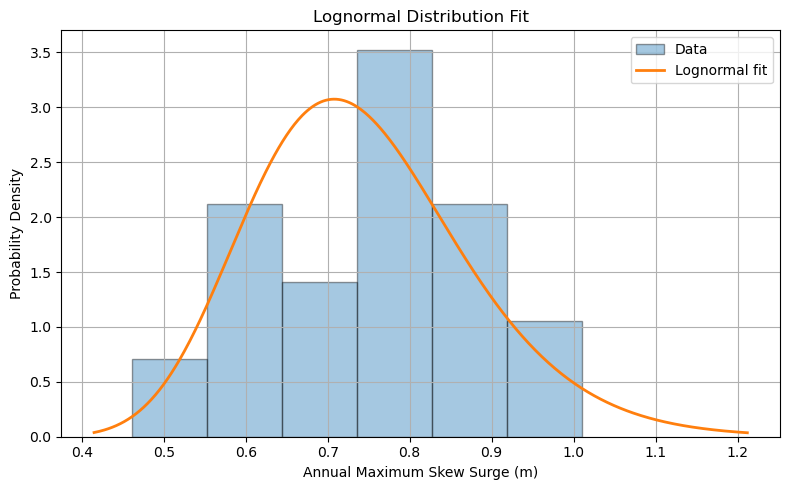

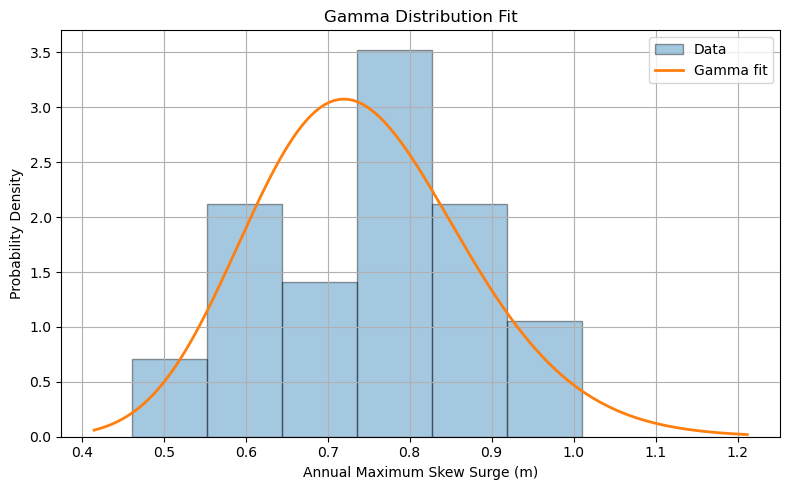

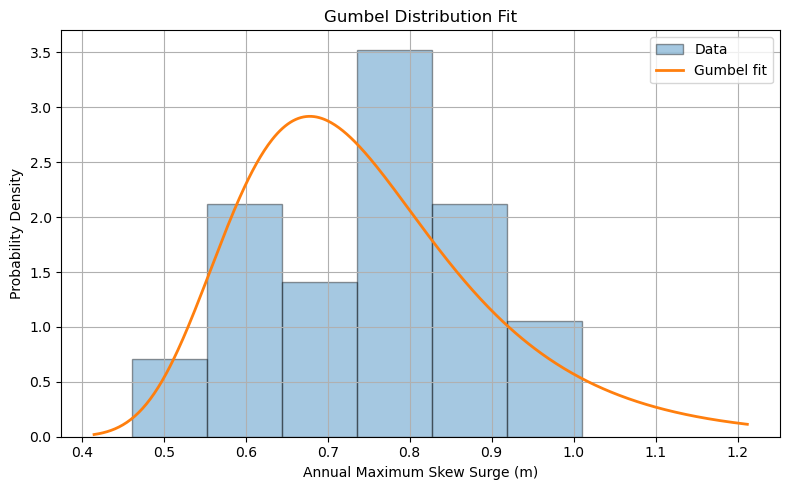

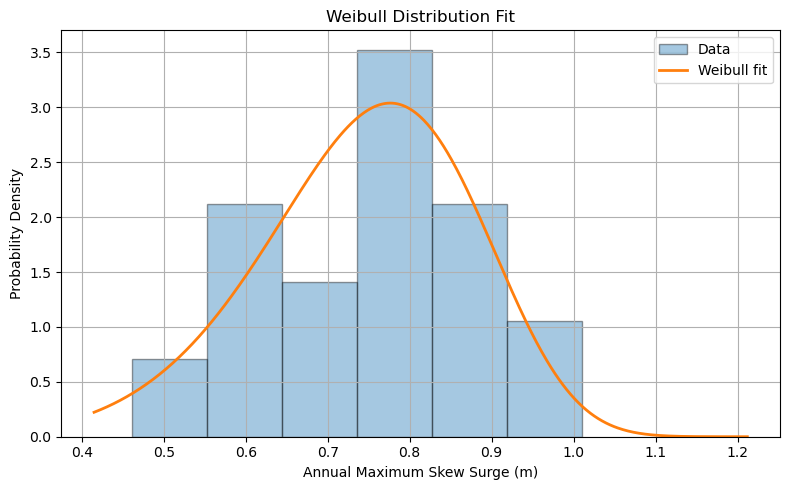

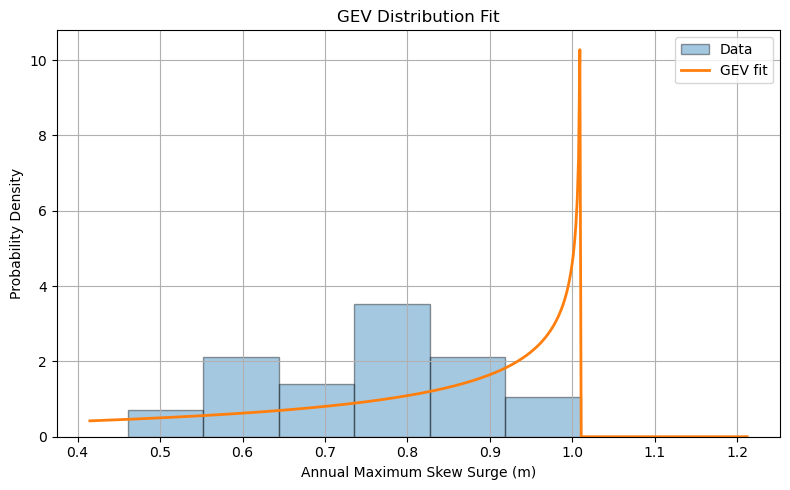

In [9]:
# =========================================================
# Individual plots for each distribution
# =========================================================

import os

# Optional: save plots
save_dir = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\plots"
os.makedirs(save_dir, exist_ok=True)

# Common x range
x_plot_min = max(0, np.min(x) * 0.9)
x_plot_max = np.max(x) * 1.2
x_plot = np.linspace(x_plot_min, x_plot_max, 500)

for name, item in fit_results.items():
    dist = item["dist"]
    params = item["params"]
    data_used = item["data"]

    plt.figure(figsize=(8,5))

    # Histogram
    plt.hist(data_used, bins="auto", density=True,
             alpha=0.4, edgecolor="black", label="Data")

    # PDF
    pdf = dist.pdf(x_plot, *params)
    plt.plot(x_plot, pdf, linewidth=2, label=f"{name} fit")

    # Labels
    plt.xlabel("Annual Maximum Skew Surge (m)")
    plt.ylabel("Probability Density")
    plt.title(f"{name} Distribution Fit")

    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    # Save figure
    file_name = os.path.join(save_dir, f"{name}_fit.png")
    plt.savefig(file_name, dpi=300)

    plt.show()

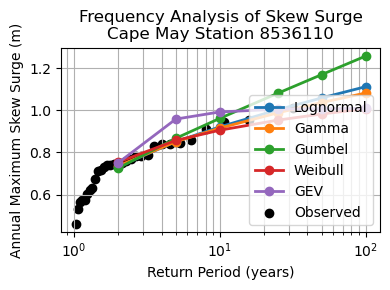

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Define return periods
# -----------------------------
T = np.array([2, 5, 10, 25, 50, 100])   # years
P = 1 - 1/T   # non-exceedance probability

# -----------------------------
# Create plot
# -----------------------------
plt.figure(figsize=(4,3))

# Plot each distribution
for name, item in fit_results.items():
    dist = item["dist"]
    params = item["params"]

    # Compute return levels
    return_levels = dist.ppf(P, *params)

    plt.plot(T, return_levels, marker='o', linewidth=2, label=name)

# -----------------------------
# Plot observed data (empirical)
# -----------------------------
# Sort annual maxima
x_sorted = np.sort(x)
n = len(x_sorted)

# Weibull plotting position
T_empirical = (n + 1) / np.arange(n, 0, -1)

plt.scatter(T_empirical, x_sorted, color='black', label="Observed")

# -----------------------------
# Formatting
# -----------------------------
plt.xscale("log")

plt.xlabel("Return Period (years)")
plt.ylabel("Annual Maximum Skew Surge (m)")
plt.title("Frequency Analysis of Skew Surge\nCape May Station 8536110")

plt.grid(True, which="both")
plt.legend()

plt.tight_layout()
plt.show()


Skew surge for different return periods:

 Return Period (yr)  Lognormal    Gamma   Gumbel  Weibull      GEV
                2.0   0.731337 0.735197 0.724315 0.752900 0.749165
                5.0   0.851189 0.850711 0.867194 0.857102 0.958641
               10.0   0.921463 0.915592 0.961793 0.905663 0.992487
               25.0   1.002805 0.988263 1.081318 0.953573 1.005503
               50.0   1.059132 1.037148 1.169989 0.982622 1.008360
              100.0   1.112494 1.082435 1.258005 1.007599 1.009397

Lognormal distribution return levels:
 Return Period (yr)  Skew Surge (m)
                2.0        0.731337
                5.0        0.851189
               10.0        0.921463
               25.0        1.002805
               50.0        1.059132
              100.0        1.112494

Gamma distribution return levels:
 Return Period (yr)  Skew Surge (m)
                2.0        0.735197
                5.0        0.850711
               10.0        0.915592
               25.

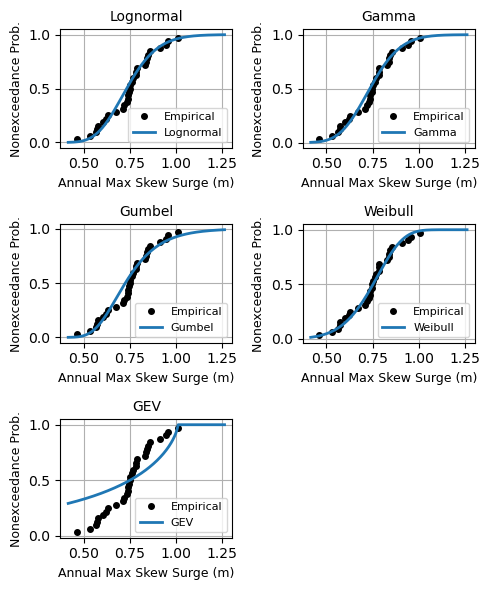

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# =========================================================
# SETTINGS
# =========================================================
save_dir = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\frequency_plots"
os.makedirs(save_dir, exist_ok=True)

# Return periods you want
return_periods = np.array([2, 5, 10, 25, 50, 100], dtype=float)
nonexceed = 1 - 1 / return_periods

# =========================================================
# EMPIRICAL CDF
# =========================================================
x_sorted = np.sort(x)
n = len(x_sorted)
empirical_cdf = np.arange(1, n + 1) / (n + 1)

# Smooth x range for fitted curves
x_plot = np.linspace(max(0, x.min() * 0.9), x.max() * 1.25, 500)

# =========================================================
# PRINT RETURN LEVELS
# =========================================================
print("\nSkew surge for different return periods:\n")

return_level_table = pd.DataFrame({"Return Period (yr)": return_periods})

for name, item in fit_results.items():
    dist = item["dist"]
    params = item["params"]
    rl = dist.ppf(nonexceed, *params)
    return_level_table[name] = rl

print(return_level_table.to_string(index=False))

# Save combined table
return_level_table.to_csv(
    os.path.join(save_dir, "return_levels_all_distributions.csv"),
    index=False
)

# =========================================================
# SAVE INDIVIDUAL RETURN LEVEL TABLES
# =========================================================
for name, item in fit_results.items():
    dist = item["dist"]
    params = item["params"]

    rl = dist.ppf(nonexceed, *params)

    df_rl = pd.DataFrame({
        "Return Period (yr)": return_periods,
        "Skew Surge (m)": rl
    })

    print(f"\n{name} distribution return levels:")
    print(df_rl.to_string(index=False))

    df_rl.to_csv(
        os.path.join(save_dir, f"ReturnLevels_{name}.csv"),
        index=False
    )

# =========================================================
# 3x2 PANEL CDF COMPARISON PLOTS
# =========================================================
fig, axes = plt.subplots(3, 2, figsize=(5, 6))
axes = axes.flatten()

dist_names = list(fit_results.keys())

for i, name in enumerate(dist_names):
    ax = axes[i]

    item = fit_results[name]
    dist = item["dist"]
    params = item["params"]

    fitted_cdf = dist.cdf(x_plot, *params)

    ax.plot(x_sorted, empirical_cdf, 'ko', markersize=4, label="Empirical")
    ax.plot(x_plot, fitted_cdf, linewidth=2, label=name)

    ax.set_xlabel("Annual Max Skew Surge (m)", fontsize=9)
    ax.set_ylabel("Nonexceedance Prob.", fontsize=9)
    ax.set_title(name, fontsize=10)
    ax.grid(True)
    ax.legend(fontsize=8)

# Hide unused subplot if only 5 distributions
if len(dist_names) < len(axes):
    for j in range(len(dist_names), len(axes)):
        axes[j].axis("off")

plt.tight_layout()

# Save figure
panel_file = os.path.join(save_dir, "CDF_Comparison_3x2_panel.png")
plt.savefig(panel_file, dpi=300, bbox_inches="tight")

plt.show()

In [1]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
from scipy import stats

# =========================================================
# File path
# =========================================================
file_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\cape_may_noaa\cape_may_8536110_observed_and_predicted_hourly_1995_2025_MSL_metric_GMT.csv"

# =========================================================
# Read data
# =========================================================
df = pd.read_csv(file_path)

# Convert time
df["Date Time"] = pd.to_datetime(df["Date Time"], errors="coerce")

# Remove NaN
df = df.dropna(subset=["observed_wl_m", "predicted_wl_m"])

# Sort
df = df.sort_values("Date Time")

# =========================================================
# Extract arrays
# =========================================================
time = df["Date Time"]
obs = df["observed_wl_m"].values
pred = df["predicted_wl_m"].values

# =========================================================
# Find peaks (high tides)
# =========================================================
obs_peaks, _ = find_peaks(obs, distance=8)
pred_peaks, _ = find_peaks(pred, distance=8)

# Create peak dataframes
obs_df = pd.DataFrame({
    "time_obs": time.iloc[obs_peaks].values,
    "obs_high": obs[obs_peaks]
})

pred_df = pd.DataFrame({
    "time_pred": time.iloc[pred_peaks].values,
    "pred_high": pred[pred_peaks]
})

# =========================================================
# Daily grouping
# =========================================================
obs_df["date"] = pd.to_datetime(obs_df["time_obs"]).dt.floor("D")
pred_df["date"] = pd.to_datetime(pred_df["time_pred"]).dt.floor("D")

# =========================================================
# Higher High Water (HHW)
# =========================================================
obs_hhw = obs_df.loc[obs_df.groupby("date")["obs_high"].idxmax()]
pred_hhw = pred_df.loc[pred_df.groupby("date")["pred_high"].idxmax()]

# =========================================================
# Merge and compute skew surge
# =========================================================
skew = pd.merge(obs_hhw, pred_hhw, on="date", how="inner")

skew["skew_surge"] = skew["obs_high"] - skew["pred_high"]
skew["year"] = skew["date"].dt.year

# =========================================================
# Annual maximum skew surge
# =========================================================
annual_max = skew.groupby("year")["skew_surge"].max().dropna()

x = annual_max.values

print("\nAnnual maximum skew surge:")
print(annual_max)

# =========================================================
# Fit Weibull distribution
# =========================================================
# Use only positive values
x_pos = x[x > 0]

params_weibull = stats.weibull_min.fit(x_pos, floc=0)

shape, loc, scale = params_weibull

print("\nWeibull parameters:")
print(f"Shape (k) = {shape:.4f}")
print(f"Scale (λ) = {scale:.4f}")

# =========================================================
# Compute 100-year skew surge
# =========================================================
T = 100
p = 1 - 1/T   # 0.99

z100 = stats.weibull_min.ppf(p, shape, loc, scale)

print(f"\n100-year skew surge (Weibull) = {z100:.3f} m")


Annual maximum skew surge:
year
1995    0.738
1996    0.751
1997    0.573
1998    1.010
1999    0.622
2000    0.831
2001    0.532
2002    0.461
2003    0.574
2004    0.847
2005    0.672
2006    0.602
2007    0.563
2008    0.857
2009    0.839
2010    0.787
2011    0.746
2012    0.945
2013    0.732
2014    0.710
2015    0.629
2016    0.956
2017    0.783
2018    0.768
2019    0.910
2020    0.718
2021    0.842
2022    0.784
2023    0.761
2024    0.739
2025    0.749
Name: skew_surge, dtype: float64

Weibull parameters:
Shape (k) = 6.4988
Scale (λ) = 0.7966

100-year skew surge (Weibull) = 1.008 m


C:\Users\sahad2\AppData\Local\Temp\ipykernel_39384\2439535747.py:36: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\sahad2\AppData\Local\Temp\ipykernel_39384\2439535747.py:36: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\sahad2\AppData\Local\Temp\ipykernel_39384\2439535747.py:36: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\sahad2\AppData\Local\Temp\ipykernel_39384\2439535747.py:36: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\sahad2\AppData\Local\Temp\ipykernel_39384\2439535747.py:36: FutureW


Annual Maximum Significant Wave Height:
[6.36 7.38 7.8  4.97 6.11 8.41 4.67 4.92 4.49 4.31 4.68 5.64 6.33 5.76
 5.24]


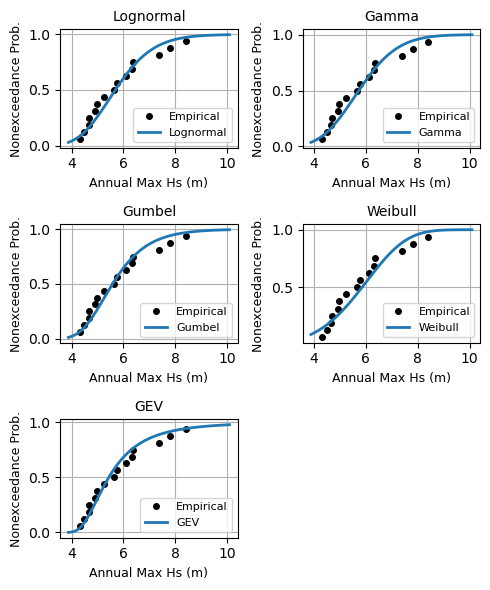

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

# =========================================================
# File paths
# =========================================================
files = [
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2011.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2012.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2013.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2014.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2015.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2016.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2017.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2018.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2019.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2020.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2021.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2022.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2023.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2024.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2025.txt"
]

# =========================================================
# Extract annual maximum WVHT
# =========================================================
annual_max = []

for file in files:
    year = os.path.basename(file).split(".")[0]

    df = pd.read_csv(
        file,
        delim_whitespace=True,
        skiprows=[1],   # skip unit row
        engine='python'
    )

    # Convert WVHT
    df["WVHT"] = pd.to_numeric(df["WVHT"], errors="coerce")

    # Remove invalid values
    df = df[(df["WVHT"].notna()) & (df["WVHT"] != 99.00)]

    if len(df) > 0:
        max_val = df["WVHT"].max()
        annual_max.append(max_val)

annual_max = np.array(annual_max)

print("\nAnnual Maximum Significant Wave Height:")
print(annual_max)

# =========================================================
# Prepare data
# =========================================================
x = annual_max
x_sorted = np.sort(x)
n = len(x_sorted)
empirical_cdf = np.arange(1, n+1)/(n+1)

x_plot = np.linspace(x.min()*0.9, x.max()*1.2, 500)

# =========================================================
# Fit distributions
# =========================================================
fit_results = {}

fit_results["Lognormal"] = (stats.lognorm, stats.lognorm.fit(x, floc=0))
fit_results["Gamma"] = (stats.gamma, stats.gamma.fit(x, floc=0))
fit_results["Gumbel"] = (stats.gumbel_r, stats.gumbel_r.fit(x))
fit_results["Weibull"] = (stats.weibull_min, stats.weibull_min.fit(x, floc=0))
fit_results["GEV"] = (stats.genextreme, stats.genextreme.fit(x))

# =========================================================
# 3x2 Panel Plot (CDF comparison)
# =========================================================
fig, axes = plt.subplots(3, 2, figsize=(5, 6))
axes = axes.flatten()

names = list(fit_results.keys())

for i, name in enumerate(names):
    ax = axes[i]

    dist, params = fit_results[name]
    cdf = dist.cdf(x_plot, *params)

    ax.plot(x_sorted, empirical_cdf, 'ko', markersize=4, label="Empirical")
    ax.plot(x_plot, cdf, linewidth=2, label=name)

    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Annual Max Hs (m)", fontsize=9)
    ax.set_ylabel("Nonexceedance Prob.", fontsize=9)

    ax.grid(True)
    ax.legend(fontsize=8)

# Remove empty subplot (6th)
if len(names) < 6:
    axes[-1].axis("off")

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
import numpy as np
from scipy import stats
import os

# =========================================================
# File paths
# =========================================================
files = [
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2011.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2012.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2013.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2014.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2015.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2016.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2017.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2018.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2019.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2020.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2021.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2022.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2023.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2024.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2025.txt"
]

# =========================================================
# Extract annual max WVHT
# =========================================================
annual_max = []

for file in files:
    year = os.path.basename(file).split(".")[0]

    df = pd.read_csv(
        file,
        delim_whitespace=True,
        skiprows=[1],
        engine='python'
    )

    df["WVHT"] = pd.to_numeric(df["WVHT"], errors="coerce")

    df = df[(df["WVHT"].notna()) & (df["WVHT"] != 99.00)]

    if len(df) > 0:
        annual_max.append(df["WVHT"].max())

x = np.array(annual_max)

print("\nAnnual Max Hs:")
print(x)

# =========================================================
# Fit distributions
# =========================================================
fit_results = {}

fit_results["Lognormal"] = (stats.lognorm, stats.lognorm.fit(x, floc=0))
fit_results["Gamma"] = (stats.gamma, stats.gamma.fit(x, floc=0))
fit_results["Gumbel"] = (stats.gumbel_r, stats.gumbel_r.fit(x))
fit_results["Weibull"] = (stats.weibull_min, stats.weibull_min.fit(x, floc=0))
fit_results["GEV"] = (stats.genextreme, stats.genextreme.fit(x))

# =========================================================
# Return periods
# =========================================================
T = np.array([2, 5, 10, 25, 50, 100], dtype=float)
P = 1 - 1/T

# =========================================================
# Create table
# =========================================================
table = pd.DataFrame({"Return Period (yr)": T})

for name, (dist, params) in fit_results.items():
    table[name] = dist.ppf(P, *params)

# Round for clean output
table = table.round(6)

print("\nReturn Level Table (Significant Wave Height):\n")
print(table.to_string(index=False))

C:\Users\sahad2\AppData\Local\Temp\ipykernel_39384\4113367189.py:35: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\sahad2\AppData\Local\Temp\ipykernel_39384\4113367189.py:35: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\sahad2\AppData\Local\Temp\ipykernel_39384\4113367189.py:35: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\sahad2\AppData\Local\Temp\ipykernel_39384\4113367189.py:35: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\sahad2\AppData\Local\Temp\ipykernel_39384\4113367189.py:35: FutureW


Annual Max Hs:
[6.36 7.38 7.8  4.97 6.11 8.41 4.67 4.92 4.49 4.31 4.68 5.64 6.33 5.76
 5.24]

Return Level Table (Significant Wave Height):

 Return Period (yr)  Lognormal    Gamma   Gumbel  Weibull       GEV
                2.0   5.685465 5.725117 5.580675 5.857419  5.438795
                5.0   6.732926 6.766170 6.615516 6.953932  6.593312
               10.0   7.355143 7.356820 7.300672 7.480223  7.559552
               25.0   8.082146 8.022746 8.166367 8.008494  9.071525
               50.0   8.589566 8.473058 8.808589 8.333047 10.449829
              100.0   9.073139 8.891776 9.446069 8.614596 12.080802


In [7]:
import pandas as pd
import numpy as np
import os

# =========================================================
# Given 10-year wave height
# =========================================================
Hs_10 = 7.559

lower = Hs_10 * 0.9
upper = Hs_10 * 1.1

print(f"Filtering range: {lower:.3f} m to {upper:.3f} m")

# =========================================================
# Invalid values list
# =========================================================
invalid_vals = [99, 99.0, 999, 999.0]

# =========================================================
# File paths
# =========================================================
files = [
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2011.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2012.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2013.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2014.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2015.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2016.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2017.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2018.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2019.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2020.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2021.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2022.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2023.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2024.txt",
r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_qn-5\2025.txt"
]

# =========================================================
# Collect filtered data
# =========================================================
filtered_data = []

for file in files:
    df = pd.read_csv(
        file,
        delim_whitespace=True,
        skiprows=[1],
        engine="python"
    )

    # Convert columns safely
    for col in ["WVHT", "DPD", "MWD"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Remove invalid + NaN values
    df = df[
        (~df["WVHT"].isin(invalid_vals)) &
        (~df["DPD"].isin(invalid_vals)) &
        (~df["MWD"].isin(invalid_vals)) &
        (df["WVHT"].notna()) &
        (df["DPD"].notna()) &
        (df["MWD"].notna())
    ]

    # Apply wave height filter
    df_filtered = df[(df["WVHT"] >= lower) & (df["WVHT"] <= upper)]

    filtered_data.append(df_filtered)

# Combine all years
filtered_df = pd.concat(filtered_data, ignore_index=True)

print("\nNumber of extreme wave records:", len(filtered_df))

# =========================================================
# Determine ranges
# =========================================================
dpd_min = filtered_df["DPD"].min()
dpd_max = filtered_df["DPD"].max()

mwd_min = filtered_df["MWD"].min()
mwd_max = filtered_df["MWD"].max()

print("\nDominant Wave Period (DPD) Range:")
print(f"{dpd_min:.2f} s to {dpd_max:.2f} s")

print("\nWave Direction (MWD) Range:")
print(f"{mwd_min:.0f}° to {mwd_max:.0f}°")

Filtering range: 6.803 m to 8.315 m


C:\Users\sahad2\AppData\Local\Temp\ipykernel_39384\3280171246.py:47: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\sahad2\AppData\Local\Temp\ipykernel_39384\3280171246.py:47: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\sahad2\AppData\Local\Temp\ipykernel_39384\3280171246.py:47: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\sahad2\AppData\Local\Temp\ipykernel_39384\3280171246.py:47: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\sahad2\AppData\Local\Temp\ipykernel_39384\3280171246.py:47: FutureW


Number of extreme wave records: 17

Dominant Wave Period (DPD) Range:
10.81 s to 13.79 s

Wave Direction (MWD) Range:
23° to 76°
